# Optimisation of problem using 3 algorithms

#### Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sin

#### Define problem

In [2]:
problem = lambda x, y: sin(x+y) + (x-y)**2 - 1.5*x + 2.5*y + 1

#### Generate 500 random solutions and plot fitness

In [3]:
# Generate 500 random solutions in the range [-5, 5]
x = np.random.uniform(-5, 5, 500)
y = np.random.uniform(-5, 5, 500)
fitness = np.array([problem(x, y) for x, y in zip(x, y)])

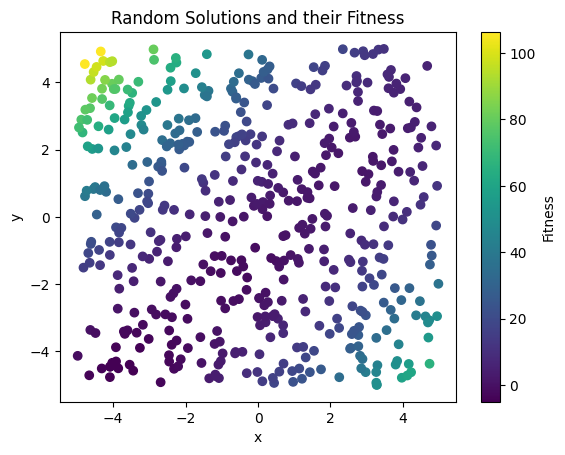

In [4]:
plt.scatter(x, y, c=fitness, cmap='viridis')
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Solutions and their Fitness')
plt.show()

#### Define hillclimber algorithm using guassian mutation

In [5]:
gmutate = lambda x: x + np.random.normal(0, 0.1)
def hillclimb(x: float, y: float, fitness_func: callable, iterations: int) -> tuple:
    best_x, best_y = x, y
    current_fitness = fitness_func(best_x, best_y)
    solutions = np.array([[], [], []]).T
    for _ in range(iterations):
        new_x = gmutate(best_x)
        new_y = gmutate(best_y)
        new_fitness = fitness_func(new_x, new_y)
        solutions = np.append(solutions, [[new_x, new_y, new_fitness]], axis=0)

        if new_fitness < current_fitness:  # Assuming we want to minimize the fitness
            best_x, best_y, current_fitness = new_x, new_y, new_fitness

    return best_x, best_y, current_fitness, solutions

#### Run hillclimber and plot fitness per solution and over time

In [6]:
init_x, init_y = np.random.uniform(-5, 5, 2)
best_x, best_y, best_fitness, solutions = hillclimb(init_x, init_y, problem, 400)
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")

Best solution: x=-3.702176507515076, y=-4.696238618648195, fitness=-5.0545931460015385


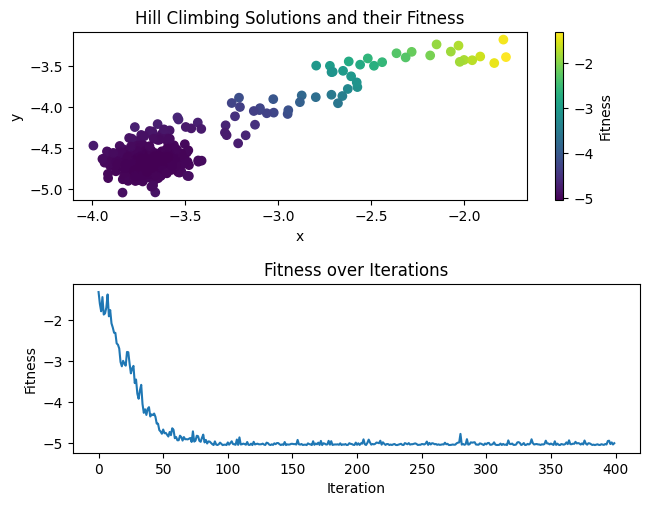

In [7]:
fig, axs = plt.subplots(2) # Plot iteration to fitness
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap='viridis')
fig.colorbar(axs[0].collections[0], label='Fitness')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Hill Climbing Solutions and their Fitness')
axs[1].plot(solutions[:, 2])
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel('Fitness')
axs[1].set_title('Fitness over Iterations')
plt.show()

#### Define evolutionary algorithm

In [8]:
def mutate_and_eval(x: float, y: float, fitness_func: callable) -> tuple:
    # Mutate x and y, then evaluate fitness
    new_x = gmutate(x)
    new_y = gmutate(y)
    new_fitness = fitness_func(new_x, new_y)
    return new_x, new_y, new_fitness

In [9]:
def evolutionary_algorithm(pop_size: int, generations: int, fitness_func: callable) -> tuple:
    pop = np.random.uniform(-5, 5, (pop_size, 2))
    fitness = np.array([fitness_func(x, y) for x, y in pop]).reshape(-1, 1)
    population = np.hstack((pop, fitness))
    best_fitness_per_gen = np.array([np.min(population[:, 2])]) 
    for _ in range(generations):
        children = np.array([mutate_and_eval(x, y, fitness_func) for x, y, _ in population]) # mutate each parent to create child and evaluate fitness
        population = np.vstack((population, children)) # combine parents and children
        population = population[np.argsort(population[:, 2])][:pop_size] # select top pop_size elements
        best_fitness_per_gen = np.append(best_fitness_per_gen, population[0, 2]) 
    best_solution = population[0]
    return best_solution[0], best_solution[1], best_solution[2], population, best_fitness_per_gen

#### Run evolutionary algorithm using 90 generations of 95 children

In [10]:
best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(95, 90, problem)
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")

Best solution: x=-3.68774745474661, y=-4.687826639313168, fitness=-5.0548138586213485


Text(0.5, 1.0, 'Best Fitness over Generations')

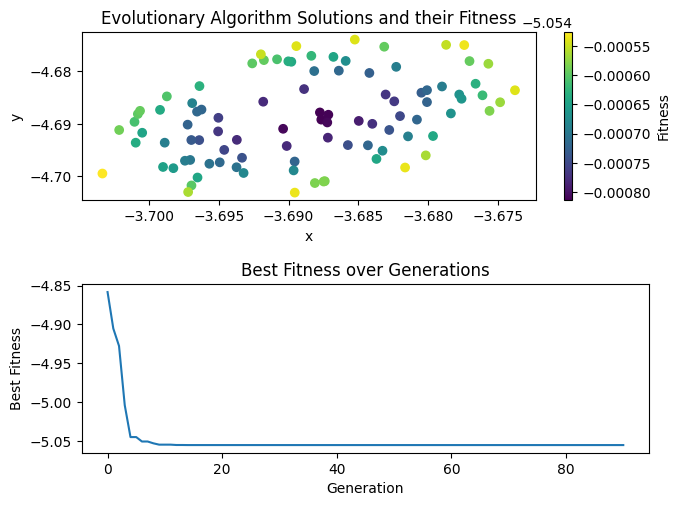

In [11]:
fig, axs = plt.subplots(2)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap='viridis')
fig.colorbar(axs[0].collections[0], label='Fitness')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Evolutionary Algorithm Solutions and their Fitness')
axs[1].plot(best_fitness_per_gen)
axs[1].set_xlabel('Generation')
axs[1].set_ylabel('Best Fitness')
axs[1].set_title('Best Fitness over Generations')

#### Run evolutionary algorithm 100 times to evaluate stability

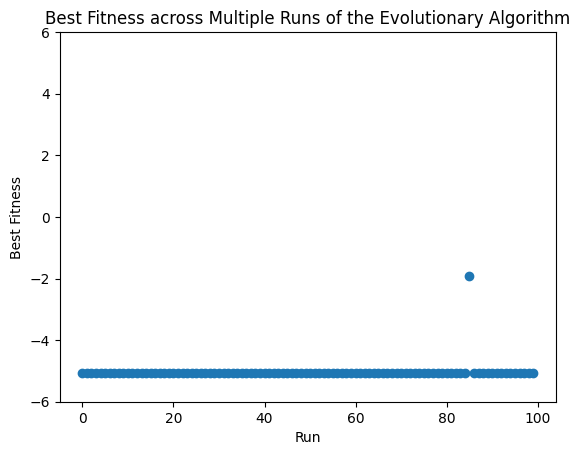

In [12]:
fitnesses = []
for i in range(100):
    best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(50, 50, problem)
    fitnesses.append((i, best_fitness))
plt.scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
plt.ylim(-6, 6)
plt.xlabel('Run')
plt.ylabel('Best Fitness')
plt.title('Best Fitness across Multiple Runs of the Evolutionary Algorithm')
plt.show()